# K-Means Clustering Algorithm with Scikit-Learn

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,accuracy_score,confusion_matrix,classification_report


In [12]:
from sklearn.datasets import make_blobs

In [13]:
df = make_blobs()

In [14]:
df

(array([[ 4.12804412,  9.68277349],
        [-6.81268293, -2.2091073 ],
        [ 6.06161568,  3.77006445],
        [-7.19601863,  1.40342198],
        [-8.10905258, -2.70707463],
        [ 7.46835784,  3.0691141 ],
        [ 6.10194282,  4.89769365],
        [-6.7097293 ,  0.01364028],
        [ 5.36567126,  6.81728564],
        [ 5.67828426,  2.71379396],
        [ 6.55123643,  2.86297245],
        [-6.95488997,  0.61297578],
        [ 4.99452561,  8.44612013],
        [ 6.13636019,  2.40931063],
        [ 6.35563937,  9.12671941],
        [ 6.82586892,  9.51197372],
        [ 6.99116729,  2.17075424],
        [ 6.21873484,  9.58845698],
        [ 7.45670727,  5.01657439],
        [-7.07407298, -0.98425999],
        [ 7.8459915 ,  2.16829252],
        [ 5.48966121,  2.97489712],
        [ 7.07296491,  4.2439412 ],
        [ 6.27050158,  8.07325035],
        [-8.40204235, -1.50640792],
        [ 6.2593067 ,  0.37290675],
        [-7.52636056, -2.16434862],
        [-7.99792836, -2.702

In [15]:
X,y_true = make_blobs(n_samples=300,centers=4,cluster_std=0.60,random_state=0)

Scale the Features so distance calculations are accurate

In [16]:
scaler = StandardScaler()
X_Scaled = scaler.fit_transform(X)

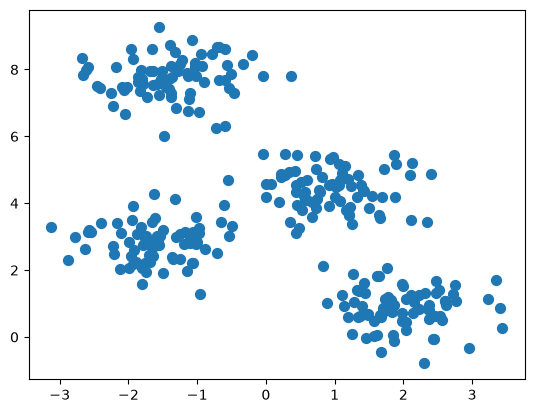

In [17]:
plt.scatter(X[:,0],X[:,1],s=50)

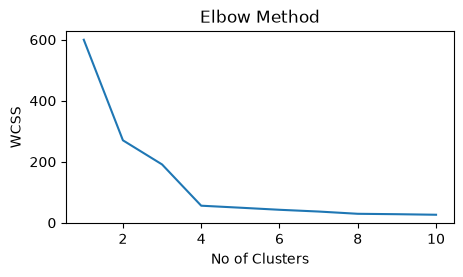

In [18]:
WCSS = []
for K in range(1,11):
    Kmeans = KMeans(n_clusters=K,init='k-means++',random_state=42)
    Kmeans.fit(X_Scaled)
    WCSS.append(Kmeans.inertia_)
    
plt.figure(figsize=(5,2.5))
plt.plot(range(1,11),WCSS)
plt.title('Elbow Method')
plt.xlabel('No of Clusters')
plt.ylabel('WCSS')
plt.show()
    

In [19]:
optimum_k = 4
Kmeans = KMeans(n_clusters=optimum_k,init='k-means++',random_state=42)

In [20]:
cluster_labels = Kmeans.fit_predict(X_Scaled)
centroids = Kmeans.cluster_centers_

print("cluster Labels: ", cluster_labels)
print(" Centroids: ",centroids)

cluster Labels:  [0 1 2 1 0 0 3 2 1 1 3 1 2 1 0 2 2 0 3 3 0 0 2 3 3 2 0 2 3 2 1 1 2 1 1 1 1
 1 3 0 2 3 2 2 3 3 1 3 1 0 3 0 1 0 0 3 1 3 1 0 1 2 1 3 3 3 1 0 1 3 2 3 1 3
 3 1 3 2 0 1 0 2 0 0 1 2 0 2 1 1 2 0 1 3 3 2 0 0 2 3 1 0 1 0 2 0 0 2 1 2 3
 3 0 1 0 2 1 0 0 2 3 0 3 0 0 0 0 3 0 3 1 3 3 0 1 3 3 1 2 1 1 3 2 3 2 3 1 2
 1 1 1 2 1 2 0 3 1 3 0 2 1 2 2 0 2 3 3 2 0 2 2 1 0 2 3 1 0 0 2 3 0 2 3 3 2
 2 2 2 0 1 2 3 2 2 3 3 3 2 3 1 2 3 0 3 2 1 3 1 2 1 2 3 2 2 1 3 3 0 0 2 1 0
 0 3 0 3 2 1 1 2 2 1 2 0 3 2 0 3 1 3 0 2 0 1 1 1 1 3 3 1 2 3 0 2 3 3 3 0 0
 1 2 2 3 0 1 3 2 1 2 0 0 3 3 2 0 0 0 2 1 1 0 0 2 0 0 0 1 3 1 2 0 0 1 1 1 0
 0 2 1 3]
 Centroids:  [[ 1.21774671 -1.19712077]
 [-0.83691948  1.46193015]
 [ 0.58536699  0.17425154]
 [-0.96619422 -0.43906093]]


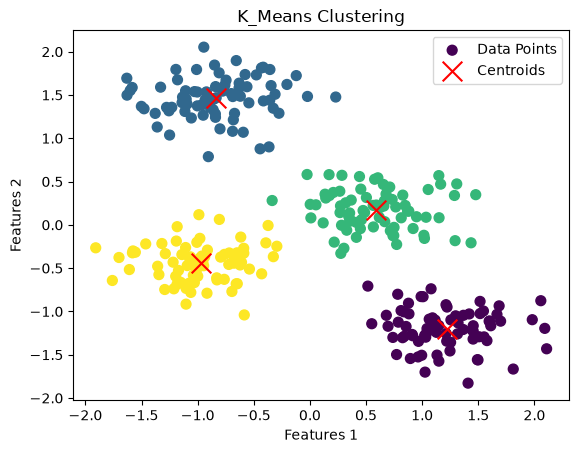

In [21]:
plt.scatter(X_Scaled[:,0],X_Scaled[:,1], s=50, c = cluster_labels,cmap='viridis');
plt.scatter(centroids[:,0],centroids[:,1],s=200,c='red',marker='x');
plt.title('K_Means Clustering');
plt.xlabel('Features 1');
plt.ylabel('Features 2');
plt.legend(['Data Points','Centroids']);
plt.show();

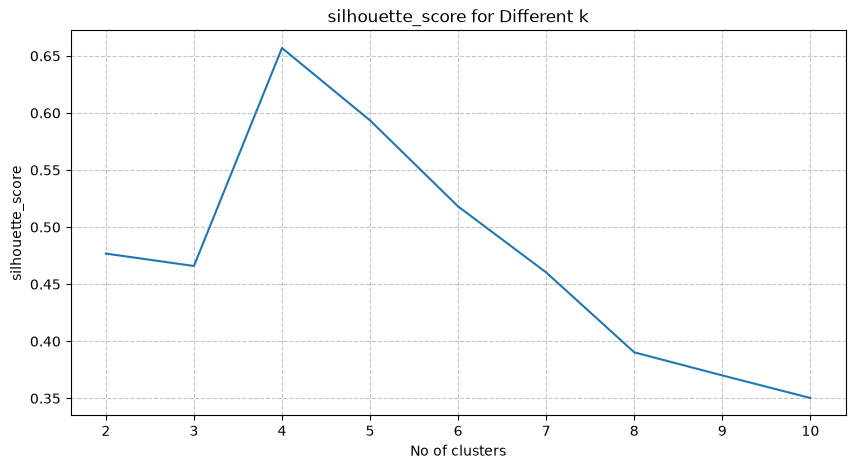

In [24]:
from sklearn.metrics import silhouette_score
silhouette_scores = []
k_range = range(2,11)

for k in k_range:
    Kmeans = KMeans(n_clusters=k,init='k-means++',random_state=42)
    Kmeans.fit(X_Scaled)
    score = silhouette_score(X_Scaled,Kmeans.labels_)
    silhouette_scores.append(score)
    
plt.figure(figsize=(10,5))
plt.plot(k_range,silhouette_scores)
plt.title('silhouette_score for Different k')
plt.xlabel('No of clusters')
plt.ylabel('silhouette_score')
plt.grid(True,linestyle = '--',alpha = 0.7)
plt.show()

In [25]:
max(silhouette_scores)

0.6569234398199433

In [26]:
min(silhouette_scores)

0.3502670446750653